# 07_hardware_constraints_depth_connectivity

Purpose:
- Understand why circuit depth and connectivity dominate NISQ performance
- See how logical circuits change when mapped to hardware
- Build intuition for why algorithm design is hardware-constrained

Original (logical) circuit depth: 1

Transpiled (hardware-mapped) circuit depth: 7

Gate counts (original): OrderedDict({'cx': 1})
Gate counts (transpiled): OrderedDict({'rz': 8, 'sx': 4, 'cx': 1})


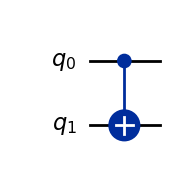

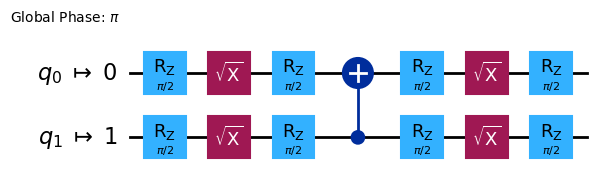

In [3]:
# Two-qubit CNOT circuit → transpile onto limited-connectivity "hardware"
# and compare circuits + depths.

%matplotlib inline

from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
#from IPython.display import display

# --- 1) Build a simple logical circuit: CNOT (control=0, target=1) ---
qc = QuantumCircuit(2)
qc.cx(0, 1)

print("Original (logical) circuit depth:", qc.depth())
#display(qc.draw(output="mpl"))
qc.draw(output="mpl")

# --- 2) Define a limited-connectivity device ---
# Example: only one directed connection 1 -> 0 is allowed (NOT 0 -> 1), opposite to what we want.
# This forces the transpiler to add extra gates to implement CX(0,1).
coupling = CouplingMap(couplinglist=[(1, 0)])

# Choose a simple basis gate set that exists on most backends
basis_gates = ["rz", "sx", "x", "cx"]

# --- 3) Transpile for the constrained device ---
qc_t = transpile(
    qc,
    coupling_map=coupling,
    basis_gates=basis_gates,
    optimization_level=0,
)

print("\nTranspiled (hardware-mapped) circuit depth:", qc_t.depth())
#display(qc_t.draw(output="mpl"))
qc_t.draw(output="mpl")

# (Optional) show how many CX gates you ended up with
print("\nGate counts (original):", qc.count_ops())
print("Gate counts (transpiled):", qc_t.count_ops())

Original circuit depth: 1


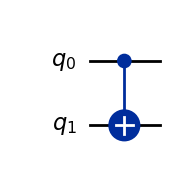


Transpiled circuit depth (undirected coupling): 1


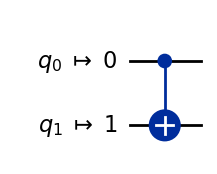


Gate counts (original): OrderedDict({'cx': 1})
Gate counts (transpiled): OrderedDict({'cx': 1})


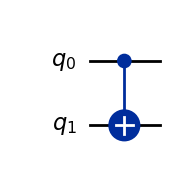

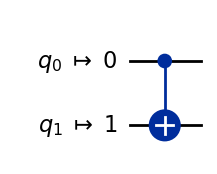

In [4]:
# Undirected connectivity example: allow CX in BOTH directions between qubits 0 and 1
# Compare transpilation result + depth.

%matplotlib inline

from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from IPython.display import display

# --- 1) Same logical circuit: CX(0 -> 1) ---
qc = QuantumCircuit(2)
qc.cx(0, 1)

print("Original circuit depth:", qc.depth())
display(qc.draw(output="mpl"))

# --- 2) "Undirected" coupling = include both directed edges ---
coupling_undirected = CouplingMap(couplinglist=[(0, 1), (1, 0)])

basis_gates = ["rz", "sx", "x", "cx"]

# --- 3) Transpile ---
qc_t = transpile(
    qc,
    coupling_map=coupling_undirected,
    basis_gates=basis_gates,
    optimization_level=0,
)

print("\nTranspiled circuit depth (undirected coupling):", qc_t.depth())
display(qc_t.draw(output="mpl"))

print("\nGate counts (original):", qc.count_ops())
print("Gate counts (transpiled):", qc_t.count_ops())

### Effects of hardware constraints after transpilation

**What changed after transpilation?**  
The transpiled circuit had increased gate count and depth due to the hardware’s connectivity and directionality constraints, which forced the transpiler to rewrite the logical circuit using additional operations.

**Why were extra gates required?**  
Extra gates were required because the hardware natively supports CNOT only in a specific direction, so the logical `cx(0,1)` had to be rewritten into an equivalent sequence that respects the allowed coupling direction.

**Which constraint hurt more here?**  
Connectivity hurt more than depth in this example. Although a CNOT gate is supported by the hardware, the directionality of the coupling prevented direct execution of the desired control–target ordering, forcing additional gates and increased depth.

In [5]:
# Parameterized single-qubit circuit with increasing depth
# Build circuits with repeated layers and print depth for each.

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

theta = Parameter("θ")

def build_depth_circuit(num_layers: int) -> QuantumCircuit:
    """
    Construct a single-qubit parameterized quantum circuit with configurable depth.

    The circuit consists of `num_layers` repeated gate layers, where each layer
    applies an RZ rotation followed by an SX gate. This pattern is representative
    of hardware-native single-qubit gate sequences on many superconducting devices.

    Args:
        num_layers (int): Number of repeated gate layers to include in the circuit.
            Each layer contributes one RZ gate and one SX gate, increasing circuit depth.

    Returns:
        QuantumCircuit: A single-qubit quantum circuit whose depth scales linearly
        with the number of layers.
    """
    qc = QuantumCircuit(1)
    for _ in range(num_layers):
        qc.rz(theta, 0)
        qc.sx(0)
    return qc

for layers in [1, 3, 5, 10, 20]:
    qc = build_depth_circuit(layers)
    print(f"layers={layers:>2} | depth={qc.depth():>2} | size={qc.size():>2}")

layers= 1 | depth= 2 | size= 2
layers= 3 | depth= 6 | size= 6
layers= 5 | depth=10 | size=10
layers=10 | depth=20 | size=20
layers=20 | depth=40 | size=40


Rule of thumb:
If a circuit looks clean on paper but explodes in depth after transpilation, it is not a NISQ algorithm.